<a href="https://colab.research.google.com/github/davidrpugh/introduction-to-deep-learning/blob/master/notebooks/03e-regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn import model_selection, preprocessing, pipeline
import torch
from torch import nn, optim, utils

In [2]:
def clip_gradients_(
    clip_grad_strategy,
    model_fn,
    clip_value=None,
    error_if_nonfinite=False,
    max_norm=None,
    norm_type=2.0):
    if clip_grad_strategy == "value" and clip_value is not None:
        nn.utils.clip_grad_value_(
            model_fn.parameters(),
            clip_value
        )
    elif clip_grad_strategy == "norm" and max_norm is not None:
        nn.utils.clip_grad_norm_(
            model_fn.parameters(),
            max_norm,
            norm_type,
            error_if_nonfinite
        )
    elif clip_grad_strategy is None:
        pass
    else:
        raise NotImplementedError()


def compute_average_loss(dataloader, loss_fn, model_fn):
    total_loss = torch.zeros(1, 1)
    for features, targets in dataloader:
        predictions = model_fn(features)
        total_loss += loss_fn(predictions, targets)
    average_loss = total_loss / len(dataloader)
    return average_loss


def initialize_linear_layer(
    in_features,
    out_features,
    init_strategy_=nn.init.kaiming_uniform_):
    linear_layer = nn.Linear(in_features, out_features)
    init_strategy_(linear_layer.weight)
    return linear_layer


def make_mlp_classifier(
    input_size,
    hidden_sizes=None,
    output_size=2,
    activation_fn=None,
    init_strategy_=nn.init.kaiming_uniform_,
    batch_normalization=False):
    modules = []
    hidden_sizes = [] if hidden_sizes is None else hidden_sizes
    for hidden_size in hidden_sizes:
        hidden_layer = initialize_linear_layer(
            input_size,
            hidden_size,
            init_strategy_,
        )
        modules.append(hidden_layer)
        if batch_normalization:
            modules.append(nn.BatchNorm1d(hidden_size))
        if activation_fn is not None:
            modules.append(activation_fn)
        input_size=hidden_size
    output_layer = initialize_linear_layer(
            input_size,
            output_size,
            init_strategy_,
    )
    modules.append(output_layer)
    modules.append(nn.LogSoftmax(dim=1))
    model_fn = nn.Sequential(*modules)
    return model_fn, nn.NLLLoss()


In [3]:
def fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    clip_grad_strategy=None,
    clip_value=None,
    error_if_nonfinite=False,
    lr_scheduler=None,
    log_epochs=1,
    max_epochs=1,
    max_norm=None,
    norm_type=2.0):

    history = {
        "epoch": [],
        "average_train_loss": [],
        "average_val_loss": []
    }

    for epoch in range(max_epochs):
        total_train_loss = torch.zeros(1, 1)
        model_fn = model_fn.train()
        for features, targets in train_dataloader:

            # forward pass
            predictions = model_fn(features)
            loss = loss_fn(predictions, targets)
            total_train_loss += loss

            # backward pass
            loss.backward()
            clip_gradients_(
                clip_grad_strategy,
                model_fn,
                clip_value,
                error_if_nonfinite,
                max_norm,
                norm_type
            )
            optimizer.step()
            optimizer.zero_grad()

        average_train_loss = total_train_loss / len(train_dataloader)
        history["epoch"].append(epoch)
        history["average_train_loss"].append(average_train_loss.item())

        # validation after every training epoch
        model_fn = model_fn.eval()
        with torch.inference_mode():
            average_val_loss = compute_average_loss(
                val_dataloader,
                loss_fn,
                model_fn
            )
        history["average_val_loss"].append(average_val_loss.item())

        # update the learning rate after every training epoch
        if lr_scheduler is not None:
            lr_scheduler.step()

        if epoch % log_epochs == 0:
            message = f"Epoch {epoch}, Average train Loss {average_train_loss.item():.4f}, Average val Loss {average_val_loss.item():.4f}"
            print(message)

    history_df = (pd.DataFrame.from_dict(history)
                              .set_index("epoch"))
    return history_df


## Load the data

In [4]:
INPUT_SIZE = 784
OUTPUT_SIZE = 10

_train_data = pd.read_csv(
    "./sample_data/mnist_train_small.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)
train_data, val_data = model_selection.train_test_split(
    _train_data,
    test_size=0.1,
    stratify=_train_data.loc[:, "label"]
)

test_data = pd.read_csv(
    "./sample_data/mnist_test.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)


In [5]:
features_preprocessor = pipeline.make_pipeline(
    preprocessing.MinMaxScaler(),
    preprocessing.FunctionTransformer(lambda arr: arr.astype(np.float32)),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)

target_preprocessor = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(lambda df: df.to_numpy()),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)


In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 2

# create the training dataset and dataloader
train_features_tensor = features_preprocessor.fit_transform(
    train_data.drop("label", axis=1)
)

train_target_tensor = target_preprocessor.fit_transform(
    train_data.loc[:, "label"]
)

train_dataset = utils.data.TensorDataset(
    train_features_tensor,
    train_target_tensor
)

train_dataloader = utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the validation dataset and dataloader
val_features_tensor = features_preprocessor.transform(
    val_data.drop("label", axis=1)
)

val_target_tensor = target_preprocessor.transform(
    val_data.loc[:, "label"]
)

val_dataset = utils.data.TensorDataset(
    val_features_tensor,
    val_target_tensor
)

val_dataloader = utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the test dataset and dataloader
test_features_tensor = features_preprocessor.transform(
    test_data.drop("label", axis=1)
)

test_target_tensor = target_preprocessor.transform(
    test_data.loc[:, "label"]
)

test_dataset = utils.data.TensorDataset(
    test_features_tensor,
    test_target_tensor
)

test_dataloader = utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)


# Regularization

## L2 Regularization via Weight Decay

### SGD

Epoch 0, Average train Loss 0.4842, Average val Loss 0.4827
Epoch 1, Average train Loss 0.3126, Average val Loss 0.4099
Epoch 2, Average train Loss 0.2882, Average val Loss 0.3779
Epoch 3, Average train Loss 0.2739, Average val Loss 0.3593
Epoch 4, Average train Loss 0.2629, Average val Loss 0.3412
Epoch 5, Average train Loss 0.2536, Average val Loss 0.3272
Epoch 6, Average train Loss 0.2456, Average val Loss 0.3166
Epoch 7, Average train Loss 0.2386, Average val Loss 0.3056
Epoch 8, Average train Loss 0.2327, Average val Loss 0.2974
Epoch 9, Average train Loss 0.2276, Average val Loss 0.2915
Epoch 10, Average train Loss 0.2233, Average val Loss 0.2858
Epoch 11, Average train Loss 0.2196, Average val Loss 0.2810
Epoch 12, Average train Loss 0.2163, Average val Loss 0.2777
Epoch 13, Average train Loss 0.2135, Average val Loss 0.2745
Epoch 14, Average train Loss 0.2110, Average val Loss 0.2722
Epoch 15, Average train Loss 0.2088, Average val Loss 0.2698
Epoch 16, Average train Loss 0.206

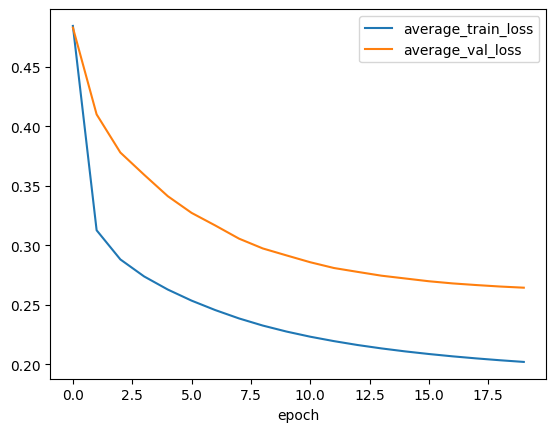

In [7]:
HIDDEN_SIZE = 100
LEARNING_RATE = 1e-1
WEIGHT_DECAY = 1e-2
MAX_EPOCHS = 20

model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_,
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)

_ = history.plot()

### AdamW

In [8]:
optim.AdamW?

Epoch 0, Average train Loss 5.9241, Average val Loss 1.2318
Epoch 1, Average train Loss 0.8584, Average val Loss 0.9186
Epoch 2, Average train Loss 0.7167, Average val Loss 0.6159
Epoch 3, Average train Loss 0.6101, Average val Loss 0.7317
Epoch 4, Average train Loss 0.6797, Average val Loss 0.7897
Epoch 5, Average train Loss 0.5098, Average val Loss 0.8311
Epoch 6, Average train Loss 0.5713, Average val Loss 0.6254
Epoch 7, Average train Loss 0.4505, Average val Loss 0.5312
Epoch 8, Average train Loss 0.4151, Average val Loss 0.5705
Epoch 9, Average train Loss 0.4500, Average val Loss 0.7221
Epoch 10, Average train Loss 0.4173, Average val Loss 0.5805
Epoch 11, Average train Loss 0.3364, Average val Loss 0.5712
Epoch 12, Average train Loss 0.3202, Average val Loss 0.5503
Epoch 13, Average train Loss 0.3138, Average val Loss 0.4703
Epoch 14, Average train Loss 0.3090, Average val Loss 0.5221
Epoch 15, Average train Loss 0.2446, Average val Loss 0.4227
Epoch 16, Average train Loss 0.224

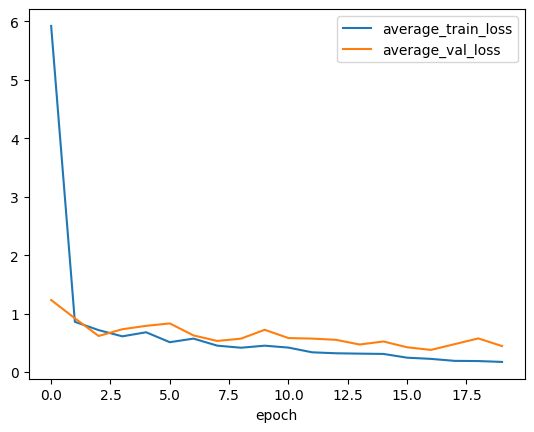

In [9]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_,
)

optimizer = optim.AdamW(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)

_ = history.plot()

## Regularization via explicit penalty

In [10]:
def fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    clip_grad_strategy=None,
    clip_value=None,
    error_if_nonfinite=False,
    lr_scheduler=None,
    log_epochs=1,
    max_epochs=1,
    max_norm=None,
    norm_type=2.0,
    penalty_fn=None,
    eta=1e-2):

    history = {
        "epoch": [],
        "average_train_loss": [],
        "average_val_loss": []
    }

    for epoch in range(max_epochs):
        total_train_loss = torch.zeros(1, 1)
        model_fn = model_fn.train()
        for features, targets in train_dataloader:

            # forward pass
            predictions = model_fn(features)
            loss = loss_fn(predictions, targets)
            total_train_loss += loss

            # add a penalty term
            if penalty_fn is not None:
                cost = loss + eta * penalty_fn(model_fn.parameters())
            else:
                cost = loss

            # backward pass
            cost.backward()
            clip_gradients_(
                clip_grad_strategy,
                model_fn,
                clip_value,
                error_if_nonfinite,
                max_norm,
                norm_type
            )
            optimizer.step()
            optimizer.zero_grad()

        average_train_loss = total_train_loss / len(train_dataloader)
        history["epoch"].append(epoch)
        history["average_train_loss"].append(average_train_loss.item())

        # validation after every training epoch
        model_fn = model_fn.eval()
        with torch.inference_mode():
            average_val_loss = compute_average_loss(
                val_dataloader,
                loss_fn,
                model_fn
            )
        history["average_val_loss"].append(average_val_loss.item())

        # update the learning rate after every training epoch
        if lr_scheduler is not None:
            lr_scheduler.step()

        if epoch % log_epochs == 0:
            message = f"Epoch {epoch}, Average train Loss {average_train_loss.item():.4f}, Average val Loss {average_val_loss.item():.4f}"
            print(message)

    history_df = (pd.DataFrame.from_dict(history)
                              .set_index("epoch"))
    return history_df


In [11]:
def elastic_net_penalty_fn(parameters, alpha):
    params_tensor = nn.utils.parameters_to_vector(parameters)
    l1_regularization = torch.norm(params_tensor, 1)
    l2_regularization = torch.norm(params_tensor, 2)
    penalty = alpha * l1_regularization + (1 - alpha) * l2_regularization
    return penalty


Epoch 0, Average train Loss 0.4920, Average val Loss 0.5066
Epoch 1, Average train Loss 0.3608, Average val Loss 0.4965
Epoch 2, Average train Loss 0.3622, Average val Loss 0.4831
Epoch 3, Average train Loss 0.3595, Average val Loss 0.4636
Epoch 4, Average train Loss 0.3512, Average val Loss 0.4543
Epoch 5, Average train Loss 0.3417, Average val Loss 0.4340
Epoch 6, Average train Loss 0.3324, Average val Loss 0.4157
Epoch 7, Average train Loss 0.3241, Average val Loss 0.4023
Epoch 8, Average train Loss 0.3168, Average val Loss 0.3906
Epoch 9, Average train Loss 0.3101, Average val Loss 0.3781
Epoch 10, Average train Loss 0.3040, Average val Loss 0.3706
Epoch 11, Average train Loss 0.2986, Average val Loss 0.3643
Epoch 12, Average train Loss 0.2937, Average val Loss 0.3599
Epoch 13, Average train Loss 0.2891, Average val Loss 0.3549
Epoch 14, Average train Loss 0.2851, Average val Loss 0.3494
Epoch 15, Average train Loss 0.2814, Average val Loss 0.3449
Epoch 16, Average train Loss 0.277

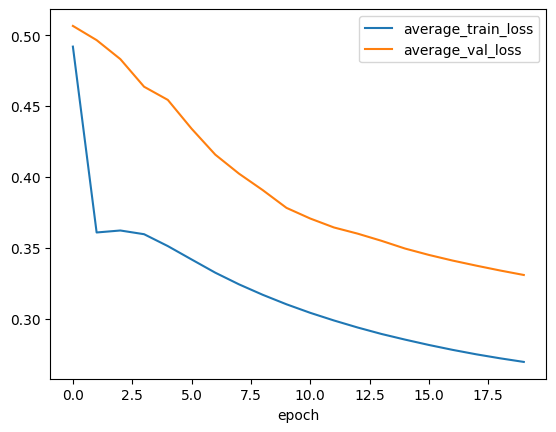

In [12]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_,
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE,
)
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS,
    penalty_fn=lambda params: elastic_net_penalty_fn(params, alpha=0.1),
    eta=1e-2
)

_ = history.plot()

## Dropout

### Dropout on the input layer

In [13]:
def make_mlp_classifier(
    input_size,
    hidden_sizes=None,
    output_size=2,
    activation_fn=None,
    init_strategy_=nn.init.kaiming_uniform_,
    batch_normalization=False,
    input_layer_dropout=False,
    dropout_prob=None):
    modules = []
    if input_layer_dropout and dropout_prob is not None:
        modules.append(nn.Dropout(dropout_prob))
    hidden_sizes = [] if hidden_sizes is None else hidden_sizes
    for hidden_size in hidden_sizes:
        hidden_layer = initialize_linear_layer(
            input_size,
            hidden_size,
            init_strategy_,
        )
        modules.append(hidden_layer)
        if batch_normalization:
            modules.append(nn.BatchNorm1d(hidden_size))
        if activation_fn is not None:
            modules.append(activation_fn)
        input_size=hidden_size
    output_layer = initialize_linear_layer(
            input_size,
            output_size,
            init_strategy_,
    )
    modules.append(output_layer)
    modules.append(nn.LogSoftmax(dim=1))
    model_fn = nn.Sequential(*modules)
    return model_fn, nn.NLLLoss()


Epoch 0, Average train Loss 0.6577, Average val Loss 0.5581
Epoch 1, Average train Loss 0.4316, Average val Loss 0.3405
Epoch 2, Average train Loss 0.3620, Average val Loss 0.4031
Epoch 3, Average train Loss 0.3085, Average val Loss 0.2299
Epoch 4, Average train Loss 0.2751, Average val Loss 0.2265
Epoch 5, Average train Loss 0.2587, Average val Loss 0.2092
Epoch 6, Average train Loss 0.2311, Average val Loss 0.1789
Epoch 7, Average train Loss 0.2148, Average val Loss 0.1679
Epoch 8, Average train Loss 0.2034, Average val Loss 0.1595
Epoch 9, Average train Loss 0.1976, Average val Loss 0.1506
Epoch 10, Average train Loss 0.1922, Average val Loss 0.1454
Epoch 11, Average train Loss 0.1884, Average val Loss 0.1462
Epoch 12, Average train Loss 0.1738, Average val Loss 0.1468
Epoch 13, Average train Loss 0.1694, Average val Loss 0.1364
Epoch 14, Average train Loss 0.1645, Average val Loss 0.1391
Epoch 15, Average train Loss 0.1621, Average val Loss 0.1333
Epoch 16, Average train Loss 0.155

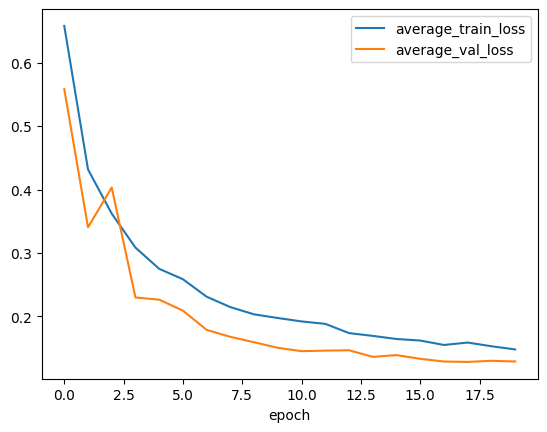

In [14]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_,
    input_layer_dropout=True,
    dropout_prob=0.5
)

optimizer = optim.SGD(model_fn.parameters(), lr=LEARNING_RATE)
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)

_ = history.plot()

### Dropout on hidden layers

In [15]:
def make_mlp_classifier(
    input_size,
    hidden_sizes=None,
    output_size=2,
    activation_fn=None,
    init_strategy_=nn.init.kaiming_uniform_,
    batch_normalization=False,
    input_layer_dropout=False,
    hidden_layer_dropout=False,
    dropout_prob=None):
    modules = []
    if input_layer_dropout and dropout_prob is not None:
        modules.append(nn.Dropout(dropout_prob))
    hidden_sizes = [] if hidden_sizes is None else hidden_sizes
    for hidden_size in hidden_sizes:
        hidden_layer = initialize_linear_layer(
            input_size,
            hidden_size,
            init_strategy_,
        )
        modules.append(hidden_layer)
        if batch_normalization:
            modules.append(nn.BatchNorm1d(hidden_size))
        if activation_fn is not None:
            modules.append(activation_fn)
        if hidden_layer_dropout and dropout_prob is not None:
            modules.append(nn.Dropout(dropout_prob))
        input_size=hidden_size
    output_layer = initialize_linear_layer(
            input_size,
            output_size,
            init_strategy_,
    )
    modules.append(output_layer)
    modules.append(nn.LogSoftmax(dim=1))
    model_fn = nn.Sequential(*modules)
    return model_fn, nn.NLLLoss()


Epoch 0, Average train Loss 1.0468, Average val Loss 0.4484
Epoch 1, Average train Loss 0.6349, Average val Loss 0.4243
Epoch 2, Average train Loss 0.5580, Average val Loss 0.4230
Epoch 3, Average train Loss 0.5302, Average val Loss 0.3742
Epoch 4, Average train Loss 0.4886, Average val Loss 0.3378
Epoch 5, Average train Loss 0.4749, Average val Loss 0.3450
Epoch 6, Average train Loss 0.4411, Average val Loss 0.3547
Epoch 7, Average train Loss 0.4353, Average val Loss 0.3272
Epoch 8, Average train Loss 0.4129, Average val Loss 0.3252
Epoch 9, Average train Loss 0.3979, Average val Loss 0.3240
Epoch 10, Average train Loss 0.3973, Average val Loss 0.3142
Epoch 11, Average train Loss 0.3843, Average val Loss 0.3135
Epoch 12, Average train Loss 0.3777, Average val Loss 0.3101
Epoch 13, Average train Loss 0.3709, Average val Loss 0.3017
Epoch 14, Average train Loss 0.3705, Average val Loss 0.3006
Epoch 15, Average train Loss 0.3627, Average val Loss 0.2984
Epoch 16, Average train Loss 0.353

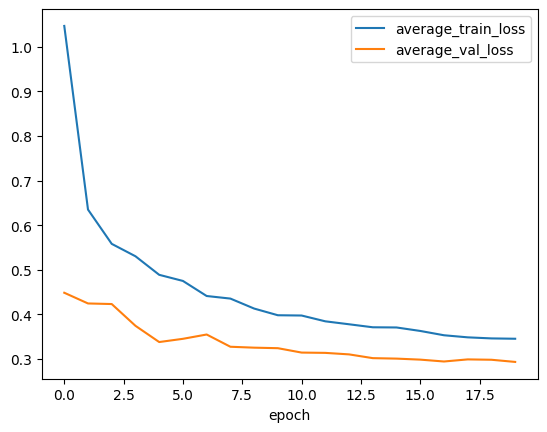

In [16]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_,
    hidden_layer_dropout=True,
    dropout_prob=0.5
)

optimizer = optim.SGD(model_fn.parameters(), lr=LEARNING_RATE)
lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    lr_scheduler=lr_scheduler,
    max_epochs=MAX_EPOCHS
)

_ = history.plot()

## Monte Carlo Dropout

In [17]:
def enable_dropout(module):
    if type(module) == nn.Dropout:
        module.train()
    else:
        pass

In [18]:
PREDICTION_SIZE = 10

model_fn = model_fn.eval()
average_test_losses = torch.zeros(PREDICTION_SIZE)

with torch.inference_mode():
    model_fn.apply(enable_dropout)
    for i in range(PREDICTION_SIZE):
        average_test_loss = compute_average_loss(
            test_dataloader,
            loss_fn,
            model_fn
        )
        average_test_losses[i] = average_test_loss.item()

In [19]:
average_test_losses.mean()

tensor(0.3844)

In [20]:
average_test_losses.std()

tensor(0.0060)